In [1]:
from qufold import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters
from qiskit.utils import algorithm_globals, QuantumInstance
from qiskit.circuit.library import RealAmplitudes
from qiskit.algorithms.optimizers import COBYLA
from qiskit.algorithms.minimum_eigensolvers import SamplingVQE
from qiskit.primitives import Sampler
import matplotlib.pyplot as plt

algorithm_globals.random_seed = 23

In [2]:
def build_pf(main_seq: str):
    """Builds the protein folding problem for the given sequence."""
    # Define the interaction
    side_chains = [""] * len(main_seq)

    mj_interaction = MiyazawaJerniganInteraction()

    penalty_back = 10
    penalty_chiral = 10
    penalty_1 = 10

    penalty_terms = PenaltyParameters(penalty_chiral, penalty_back, penalty_1)

    peptide = Peptide(main_seq, side_chains)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [3]:
main_chain_1 = "LHPGAGK"
main_chain_2 = "APRLRFY"
# main_chain = "YYDPETGTWY"
pf1 = build_pf(main_chain_1)
pf2 = build_pf(main_chain_2)

# Get the qubit operators
qubit_op_1 = pf1.qubit_op()
qubit_op_2 = pf2.qubit_op()

In [4]:
def run_vqe(qubit_op):
    # set classical optimizer
    optimizer = COBYLA(maxiter=50)

    # set variational ansatz
    ansatz = RealAmplitudes(reps=1)

    counts = []
    values = []

    def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)

    # initialize VQE using CVaR with alpha = 0.1
    vqe = SamplingVQE(
        Sampler(),
        ansatz=ansatz,
        optimizer=optimizer,
        aggregation=0.1,
        callback=store_intermediate_result,
    )

    raw_result = vqe.compute_minimum_eigenvalue(qubit_op)

    return raw_result, counts, values

In [5]:
raw_result_1, counts_1, values_1 = run_vqe(qubit_op_1)

/Users/ruihaoli/opt/miniconda3/envs/test_env/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ruihaoli/opt/miniconda3/envs/test_env/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


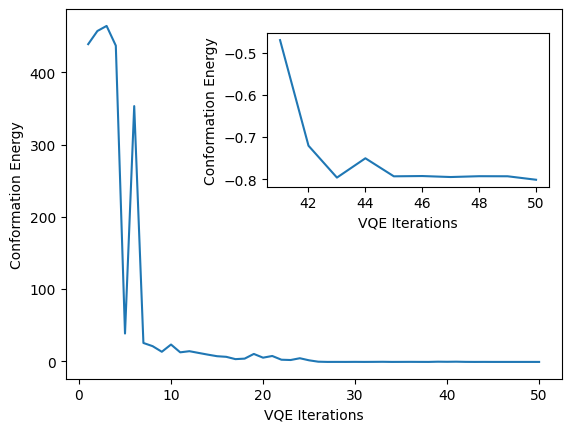

In [6]:
fig = plt.figure()

plt.plot(counts_1, values_1)
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")

fig.add_axes([0.44, 0.51, 0.44, 0.32])

plt.plot(counts_1[40:], values_1[40:])
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")
plt.show()

In [7]:
raw_result_2, counts_2, values_2 = run_vqe(qubit_op_2)

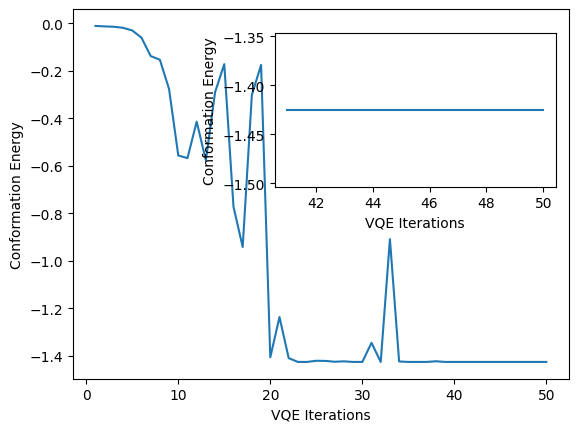

In [8]:
fig = plt.figure()

plt.plot(counts_2, values_2)
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")

fig.add_axes([0.44, 0.51, 0.44, 0.32])

plt.plot(counts_2[40:], values_2[40:])
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")
plt.show()

The bitstring representing the shape of the protein during optimization is:  101100011
The expanded expression is: 1______0_____________________________________________________________________________________________________________________________110001_1____
The folded protein's main sequence of turns is: [1, 0, 3, 2, 0, 3]
and the side turn sequences are: [None, None, None, None, None, None, None]


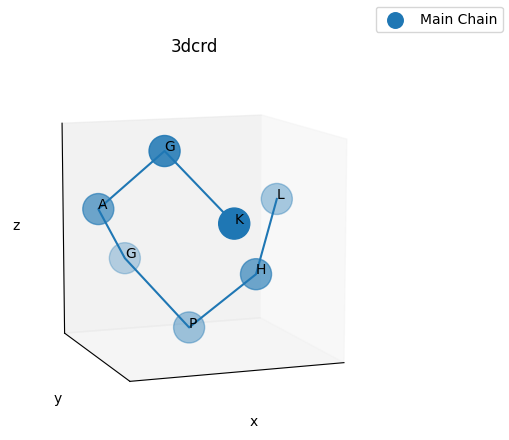

In [9]:
result = pf1.interpret(raw_result=raw_result_1)
print(
    "The bitstring representing the shape of the protein during optimization is: ",
    result.turn_sequence,
)
print("The expanded expression is:", result.get_result_binary_vector())

##

print(f"The folded protein's main sequence of turns is: {result.protein_shape_decoder.main_turns}")
print(f"and the side turn sequences are: {result.protein_shape_decoder.side_turns}")

fig = result.get_figure(title="3dcrd", ticks=False, grid=True)
fig.get_axes()[0].view_init(10, 70)

The bitstring representing the shape of the protein during optimization is:  011000101
The expanded expression is: 0______1_____________________________________________________________________________________________________________________________100010_1____
The folded protein's main sequence of turns is: [1, 0, 3, 1, 0, 1]
and the side turn sequences are: [None, None, None, None, None, None, None]


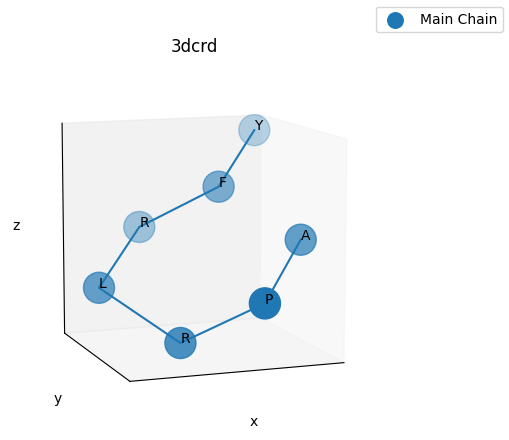

In [10]:
result = pf2.interpret(raw_result=raw_result_2)
print(
    "The bitstring representing the shape of the protein during optimization is: ",
    result.turn_sequence,
)
print("The expanded expression is:", result.get_result_binary_vector())

##

print(f"The folded protein's main sequence of turns is: {result.protein_shape_decoder.main_turns}")
print(f"and the side turn sequences are: {result.protein_shape_decoder.side_turns}")

fig = result.get_figure(title="3dcrd", ticks=False, grid=True)
fig.get_axes()[0].view_init(10, 70)